In [2]:
import numpy as np
from pylab import plt, mpl

In [6]:
import seaborn as sns
sns.set_theme(style="darkgrid")
mpl.rcParams['font.family'] = 'serif'
%matplotlib inline

In [7]:
def f(x):
    return np.sin(x) + 0.5 * x

In [15]:
def create_plot(x, y, styles, labels, axlabels):
    plt.figure(figsize=(10,6))
    for i in range(len(x)):
        plt.plot(x[i], y[i], styles[i], label=labels[i])
        plt.xlabel(axlabels[0])
        plt.ylabel(axlabels[1])
    plt.legend(loc=0)

In [16]:
x = np.linspace(-2 * np.pi, 2* np.pi, 50)

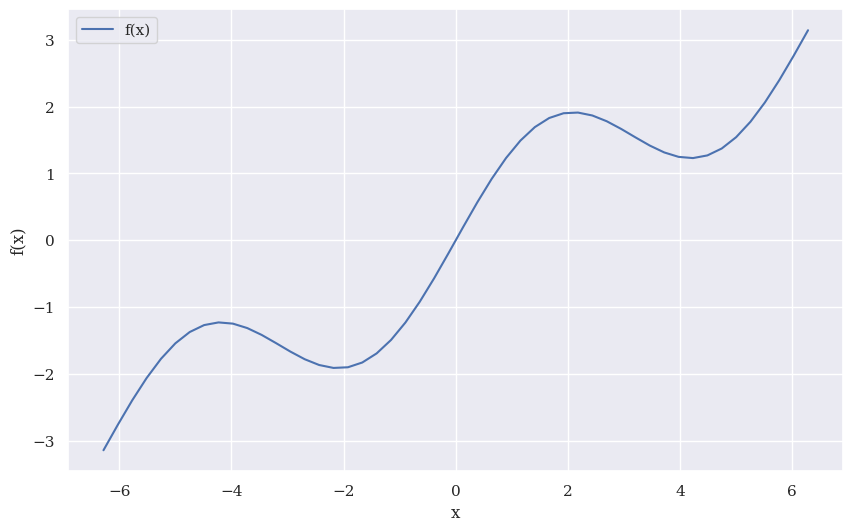

In [19]:
create_plot([x], [f(x)], ['b'], ['f(x)'], ['x','f(x)'])
plt.show()

<span style='font-size:17px'><b>Approximation: Mathematical Foundations</b>

* <b>Functional Form:</b> We define $f(x) = \sin(x) + 0.5x$, representing a function that combines a cyclical component (the sine wave) with a deterministic trend-a structure frequently used to model seasonal finance data.
* <b>Numberical Domain:</b> Using 'np.linspace', we generate a discrete set of 50 values over the interval $[-2\pi, 2\pi]$ to transform the continuous mathematical function into a coordinate-based format for Python processing.
* <b>Visualization Framework:</b> The 'create_plot' function provides a modular way to handle data series, allowing for easy visual comparison between the original 'target' function and the upcoming regression model.

In [20]:
res = np.polyfit(x, f(x), deg=1, full=True)

In [21]:
res

(array([ 4.28841952e-01, -1.40254456e-16]),
 array([21.03238686]),
 np.int32(2),
 array([1., 1.]),
 np.float64(1.1102230246251565e-14))

In [22]:
ry = np.polyval(res[0],x)

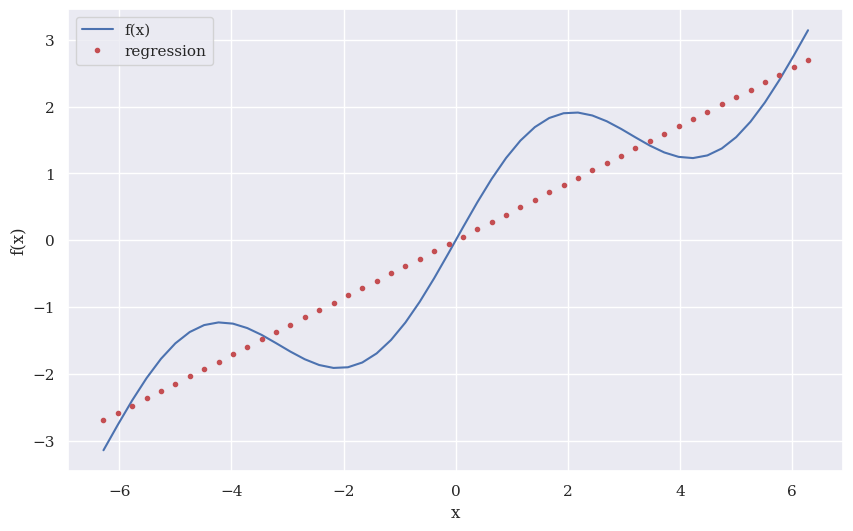

In [25]:
create_plot([x,x], [f(x), ry], ['b', 'r.'],
            ['f(x)','regression'], ['x','f(x)'])
plt.show()

In [26]:
reg = np.polyfit(x, f(x), deg=5)
ry = np.polyval(reg, x)

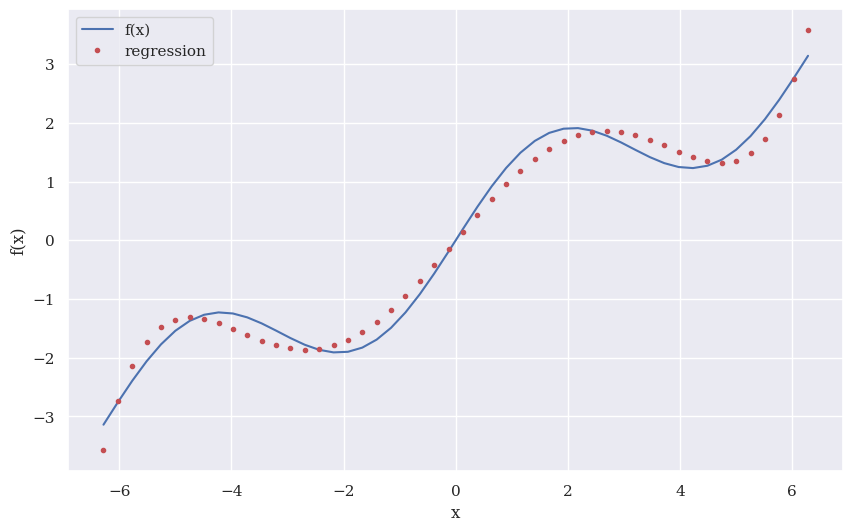

In [27]:
create_plot([x,x], [f(x), ry], ['b', 'r.'],
            ['f(x)','regression'], ['x','f(x)'])
plt.show()

In [29]:
reg = np.polyfit(x, f(x), deg=7)
ry = np.polyval(reg, x)

In [30]:
np.allclose(f(x), ry)

False

In [31]:
np.mean((f(x) - ry) ** 2)

np.float64(0.0017769134759517593)

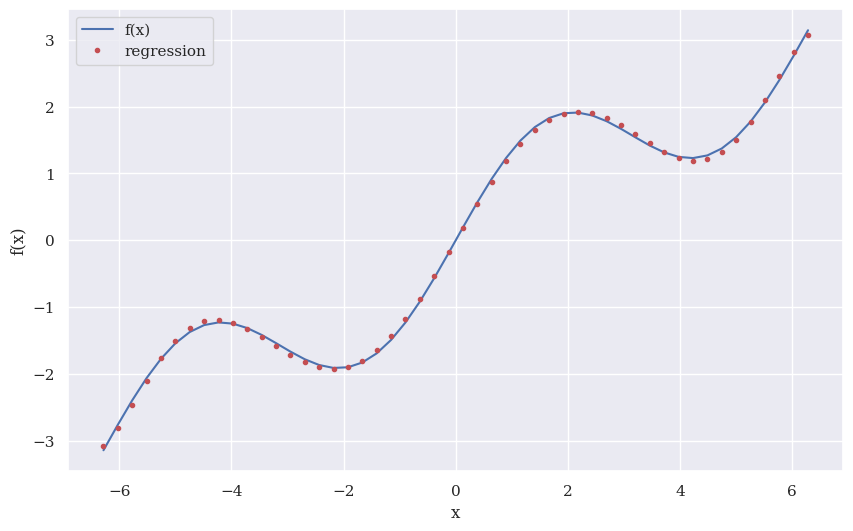

In [32]:
create_plot([x,x], [f(x), ry], ['b', 'r.'],
            ['f(x)','regression'], ['x','f(x)'])
plt.show()

<span style='font-size:17px'><b>Regression: From Linear to Polynomial Fits</b>

* <b>Degree 1 (Linear):</b> A first-degree polynomial (a straight-line) captures the general upward trend of $f(x)$ but fails to account the cyclical sine wave, resulting in a high 'residual' error.
* <b>Degree 5 & 7 (Polynomial):</b> By increasing the degree, we introduce more basis functions ($x^2, x^3, ...$). A degree-7 polynomial provides a much tighter fit, successfully tracing the curves of the sine wave while maintaining the overall linear trend.
* <b>Error Measurement:</b>We use 'np.mean((f(x) - ry) ** 2)' to calculate the **Mean Squared Error (MSE)**. As the degree increases, this value decreases, quantifying the improvement in our approximation's accuracy.
* <b>Numerical Validation:</b> 'np.allclose()' checks if the original data and the regression are identical within a small tolerance. Even with a degree-7 fit, it returns 'False', reminding us that a polynomial is an <i>approximation</i>, not an exact replication of a transcendental function like $\sin(x)$.

In [34]:
matrix = np.zeros((3 + 1, len(x)))
matrix[3, :] = x ** 3
matrix[2, :] = x ** 2
matrix[1, :] = x
matrix[0, :] = 1

In [35]:
reg = np.linalg.lstsq(matrix.T, f(x), rcond=None)[0]

In [36]:
reg.round(4)

array([ 0.    ,  0.5628, -0.    , -0.0054])

In [37]:
ry = np.dot(reg, matrix)

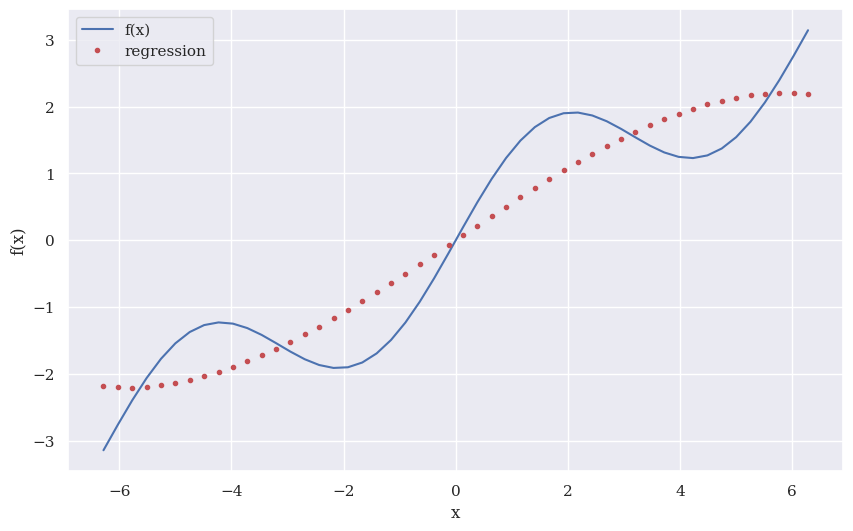

In [38]:
create_plot([x,x], [f(x), ry], ['b', 'r.'],
            ['f(x)','regression'], ['x','f(x)'])
plt.show()

In [39]:
matrix[3, :] = np.sin(x)

In [40]:
reg = np.linalg.lstsq(matrix.T, f(x), rcond=None)[0]

In [41]:
reg.round(4)

array([0. , 0.5, 0. , 1. ])

In [42]:
ry = np.dot(reg, matrix)

In [43]:
np.allclose(f(x), ry)

True

In [44]:
np.mean((f(x) - ry) ** 2)

np.float64(3.345571424993955e-31)

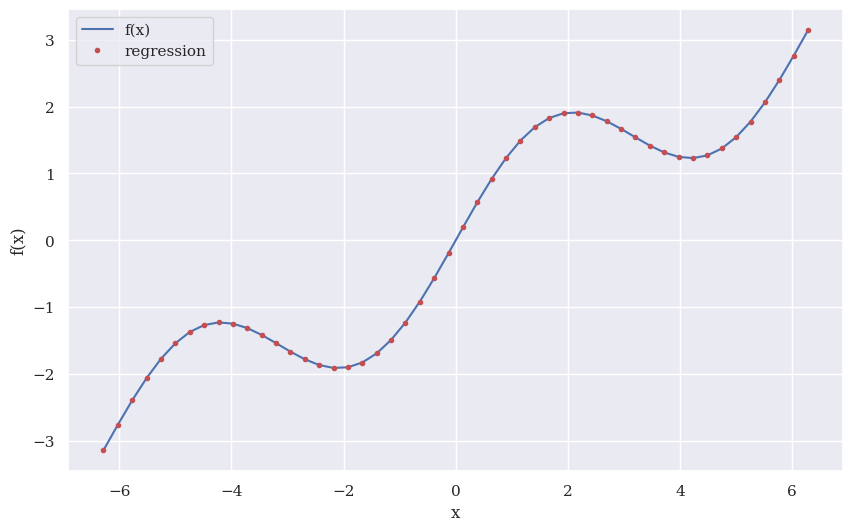

In [45]:
create_plot([x,x], [f(x), ry], ['b', 'r.'],
            ['f(x)','regression'], ['x','f(x)'])
plt.show()

<span style='font-size:17px'><b>Generalizing Basis Functions with Least-Squares</b>

* <b>Beyond Polynomials:</b> While polynomials are versatile, they aren't always the most efficient building blocks. By manually constructing a **Basis Matrix**, we can choose functions that match the known characteristics of our target data (like seasonality or oscillation).
* <b>The 'Perfect' Basis:</b> In the first plot, we use $[1, x, x^2, x^3]$. In the second, we swapped $x^3$ for $\sin(x)$. Because our original function $f(x)$ was built using a sine wave, the regression immediately found a near-perfect fit.
* <b>Numerical Precision:</b> Notice the 'np.allclose()' result is now 'True' and the Mean Squared Error (MSE) has dropped to nearly ($3.34 \times 10^{-31}$). This indicates that our model is no longer just approximating-it has successfully recovered the underlying mathematical structure.
* <b>Optimal Parameters ($\beta$):</b> The reg.round(4)' output of '[0, 0.5, 0, 1]' corresponds exactly to our function $f(x) = 0.5x + 1\sin(x)$, proving that the least-squares solver ('np.linalg.lstsq') correctly identified the original coefficients.

In [47]:
xn = np.linspace(-2 * np.pi, 2 * np.pi, 50)
xn = xn + 0.15 * np.random.standard_normal(len(xn))
yn = f(xn) + 0.25 * np.random.standard_normal(len(xn))

In [48]:
reg = np.polyfit(xn, yn, 7)
ry = np.polyval(reg, xn)

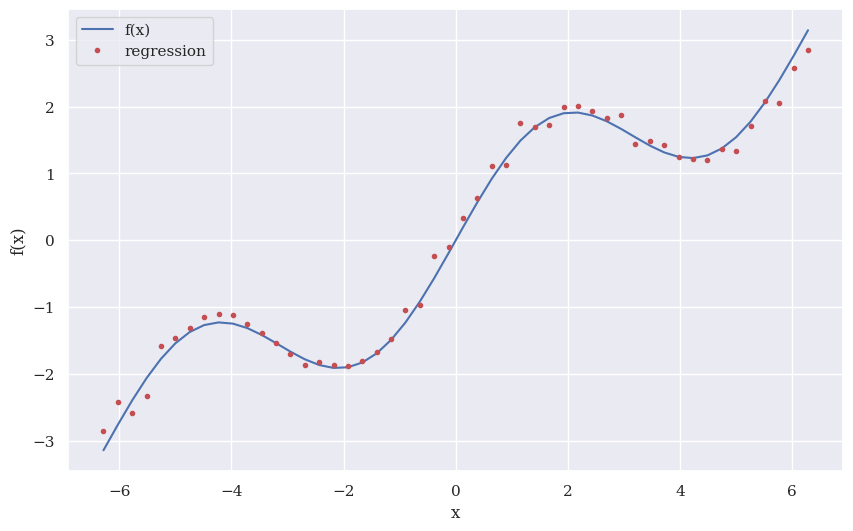

In [49]:
create_plot([x,x], [f(x), ry], ['b', 'r.'],
            ['f(x)','regression'], ['x','f(x)'])
plt.show()

In [50]:
xu = np.random.rand(50) * np.pi - 2 * np.pi
yu = f(xu)

In [51]:
print(xu[:10].round(2))
print(yu[:10].round(2))

[-4.67 -4.17 -3.37 -6.03 -3.49 -5.3  -3.96 -5.43 -3.24 -5.76]
[-1.34 -1.23 -1.46 -2.77 -1.4  -1.82 -1.25 -1.96 -1.52 -2.38]


In [52]:
reg = np.polyfit(xu, yu, 5)
ry = np.polyval(reg, xu)

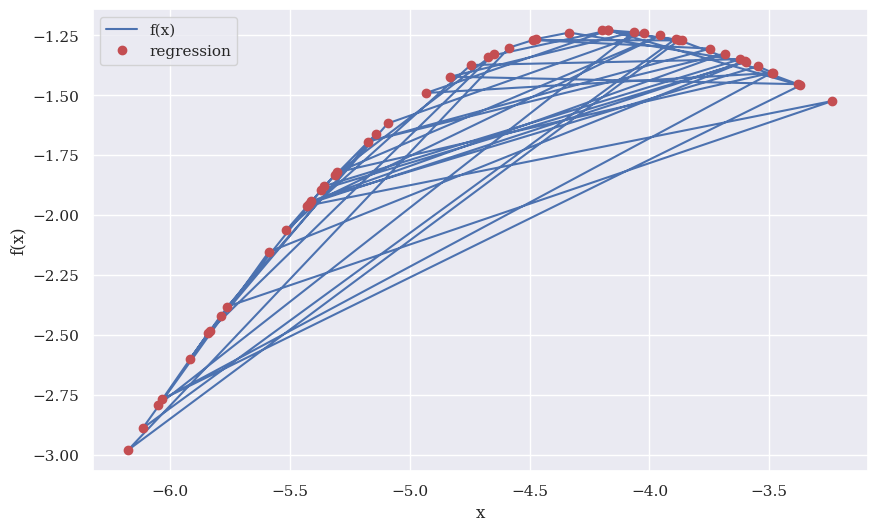

In [56]:
create_plot([xu, xu], [yu, ry], ['b', 'ro'],
            ['f(x)','regression'], ['x','f(x)'])
plt.show()